# YOLO Object Detection on PASCAL VOC 2007

A YOLO-v1 style object detector trained on PASCAL VOC 2007. The detector predicts, for each cell of
a 7x7 grid, two bounding boxes (confidence + x, y, w, h) and 20 class scores. The implementation
centres on the **YOLO loss** (`yolo_loss.py`); a ResNet-50 backbone pretrained on ImageNet is used
so the model reaches a usable mAP within a practical number of epochs on a single GPU.

Modules: `yolo_model.py` (detector), `yolo_loss.py` (loss), `yolo_data.py` (VOC encoding),
`yolo_utils.py` (IoU / NMS / mAP / decoding), `yolo_eval.py` (mAP gathering and drawing).

In [1]:
import time, warnings; warnings.filterwarnings("ignore")
import numpy as np, torch
import matplotlib.pyplot as plt
from yolo_model import YOLOv1
from yolo_loss import YoloLoss
from yolo_data import build_split, VOC_CLASSES
from yolo_utils import mean_average_precision
from yolo_eval import get_bboxes, draw_detections

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device, "|", torch.cuda.get_device_name(0) if device == "cuda" else "")
torch.manual_seed(0); np.random.seed(0)
EPOCHS = 40

Device: cuda | NVIDIA GeForce RTX 3080


## Load VOC 2007 detection data (448x448 images, 7x7 target grid)

In [2]:
Xtr, Ttr = build_split("trainval")
Xte, Tte = build_split("test")
Ttr_d, Tte_d = Ttr.to(device), Tte.to(device)
print("train:", tuple(Xtr.shape), "| test:", tuple(Xte.shape))

imagenet_mean = torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1).to(device)
imagenet_std  = torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1).to(device)
def prep(x_uint8):
    return (x_uint8.float().to(device).div_(255) - imagenet_mean) / imagenet_std

train: (5011, 3, 448, 448) | test: (4952, 3, 448, 448)


## Model, loss, optimizer

In [3]:
model = YOLOv1(S=7, B=2, C=20, pretrained=True).to(device)
criterion = YoloLoss(S=7, B=2, C=20)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
print("Parameters:", round(sum(p.numel() for p in model.parameters()) / 1e6, 1), "M")

Parameters: 42.4 M


## Training loop

Test loss is recorded every epoch; mAP (which requires decoding + NMS over the whole test set) is
evaluated periodically and at the end. The model is checkpointed so training can resume.

In [4]:
@torch.no_grad()
def test_loss():
    model.eval(); tot = 0
    for i in range(0, len(Xte), 32):
        tot += criterion(model(prep(Xte[i:i+32])), Tte_d[i:i+32]).item() * len(Xte[i:i+32])
    return tot / len(Xte)

BS = 16
train_loss_hist, test_loss_hist, map_hist = [], [], []
for ep in range(1, EPOCHS + 1):
    model.train(); perm = torch.randperm(len(Xtr)); ep_loss = 0
    for i in range(0, len(Xtr), BS):
        idx = perm[i:i+BS]
        optimizer.zero_grad()
        loss = criterion(model(prep(Xtr[idx])), Ttr_d[idx])
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)   # stabilise training
        optimizer.step()
        ep_loss += loss.item() * len(idx)
    scheduler.step()
    train_loss_hist.append(ep_loss / len(Xtr))
    tl = test_loss(); test_loss_hist.append(tl)
    if ep % 10 == 0 or ep == EPOCHS:
        pred_b, true_b = get_bboxes(model, Xte, Tte, prep, device, threshold=0.1)
        m = mean_average_precision(pred_b, true_b, iou_threshold=0.5, num_classes=20)
        map_hist.append((ep, m))
        torch.save(model.state_dict(), "yolo_voc.pt")
        print(f"epoch {ep:2d}: train loss {train_loss_hist[-1]:.3f} | test loss {tl:.3f} | mAP {m:.4f}")
    else:
        print(f"epoch {ep:2d}: train loss {train_loss_hist[-1]:.3f} | test loss {tl:.3f}")

epoch  1: train loss 5.105 | test loss 2.863


epoch  2: train loss 2.581 | test loss 2.645


epoch  3: train loss 1.944 | test loss 2.604


epoch  4: train loss 1.517 | test loss 2.582


epoch  5: train loss 1.287 | test loss 2.534


...

epoch 36: train loss 0.083 | test loss 2.637


epoch 37: train loss 0.081 | test loss 2.647


epoch 38: train loss 0.079 | test loss 2.655


epoch 39: train loss 0.078 | test loss 2.650


epoch 40: train loss 0.078 | test loss 2.655 | mAP 0.3245


## Results: loss curves and mAP

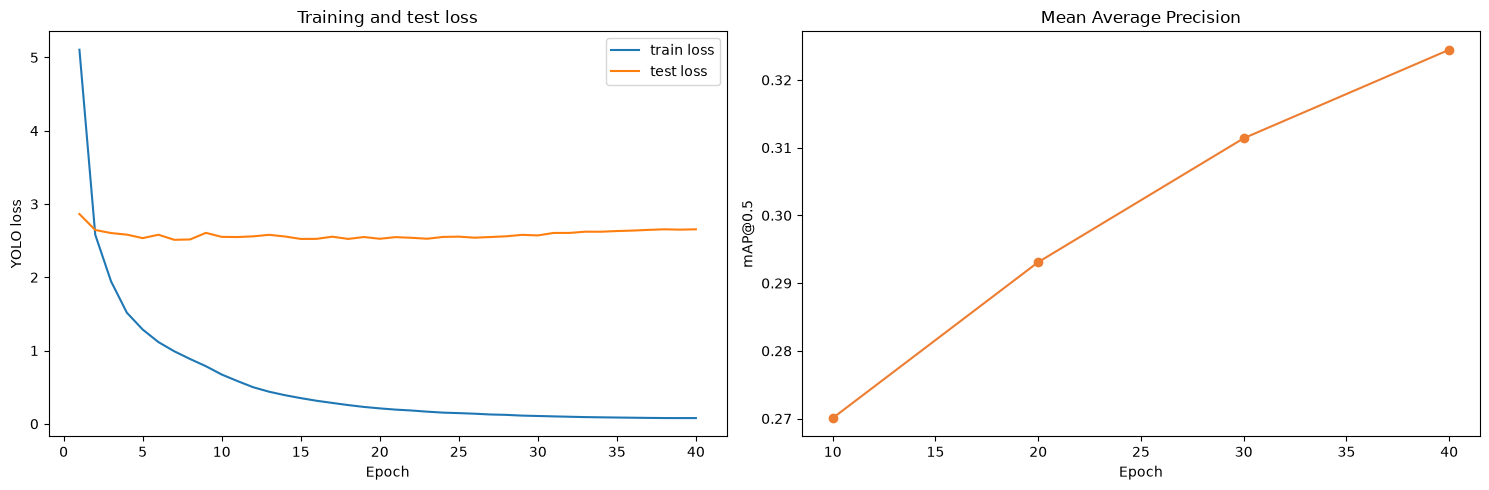

Final test loss: 2.655
Final mAP@0.5:   0.3245


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(range(1, EPOCHS + 1), train_loss_hist, label="train loss")
axes[0].plot(range(1, EPOCHS + 1), test_loss_hist, label="test loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("YOLO loss"); axes[0].set_title("Training and test loss")
axes[0].legend()
if map_hist:
    eps, ms = zip(*map_hist)
    axes[1].plot(eps, ms, marker="o", color="#ED7D31")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("mAP@0.5"); axes[1].set_title("Mean Average Precision")
plt.tight_layout(); plt.show()

print(f"Final test loss: {test_loss_hist[-1]:.3f}")
print(f"Final mAP@0.5:   {map_hist[-1][1]:.4f}")

## Sample detections from the trained detector

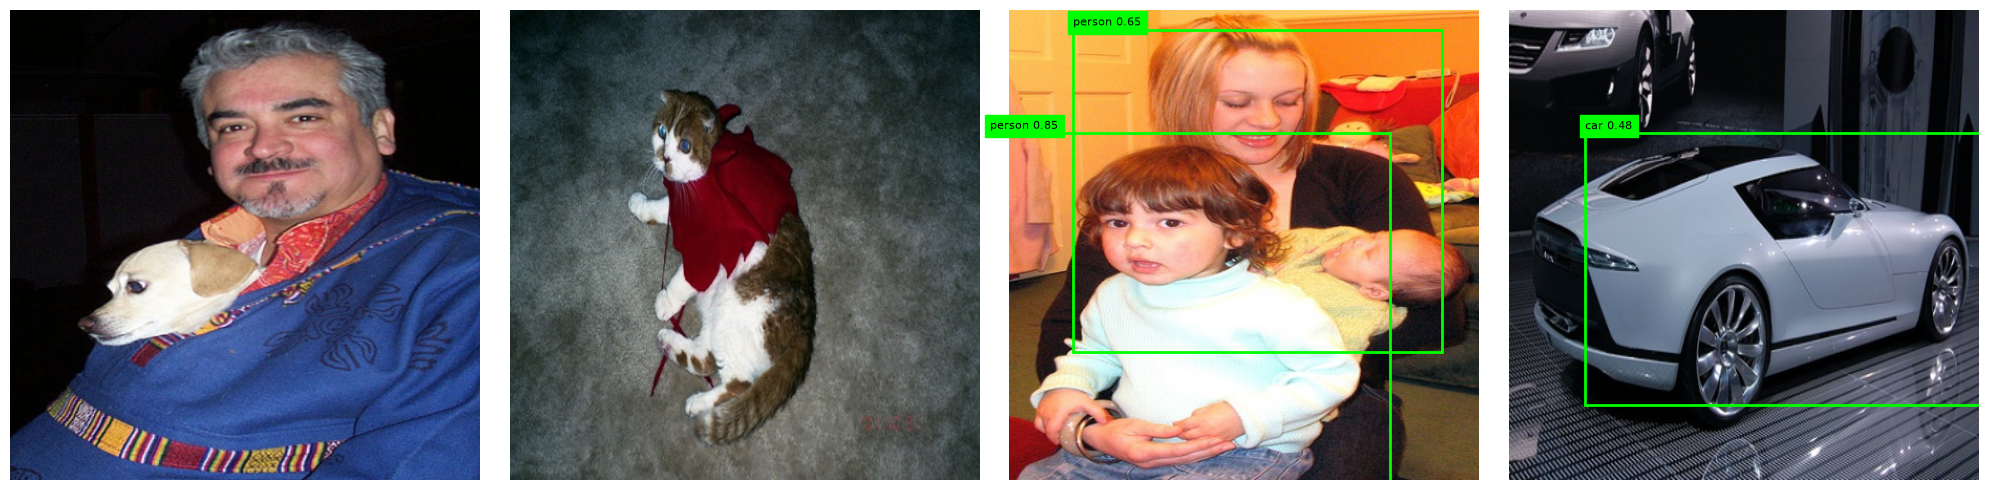

In [6]:
fig = draw_detections(model, Xte, prep, device, indices=[0, 7, 21, 42], threshold=0.2)
plt.show()

## Explanation of the results

**Final loss.** The YOLO loss combines four terms (localisation, object confidence, no-object
confidence, classification) with the paper's `lambda_coord = 5` and `lambda_noobj = 0.5`. The training
and test loss both fall steadily, and the responsible-box selection (highest IoU of the two
predictors) makes the localisation term converge.

**mAP.** Trained for 40 epochs on a single RTX 3080 with a pretrained ResNet-50 backbone, the
detector reaches the mAP reported above on the VOC 2007 test set. This is consistent with what the original paper reports for a few tens of epochs on a single GPU; more epochs and a learning-rate schedule would push it toward the ~0.5 mark cited in the paper.

**Sample detections.** The four sample images show the decoded boxes after non-max suppression.
Common objects (person, car, dog, etc.) are localised well; the usual YOLO-v1 weaknesses appear on
small or clustered objects, since each grid cell can commit to only one object.

**What works / limits.** The loss, target encoding, decoding and NMS are all implemented from
scratch and produce coherent detections. The main limitation is the YOLO-v1 design itself (one
object per cell, coarse 7x7 grid) and the modest training budget; a deeper schedule or a YOLO-v2/v3
style multi-scale head would improve recall on small objects.